# Model-Based Reinforcement Learning: Dyna, World Models, and Planning

## Introduction

In model-free RL (Q-learning, DQN, Policy Gradients), agents learn directly from real environment interactions. But what if we could **learn a model of how the environment works** and use it for planning?

**Model-based RL** learns a **world model** (also called a **dynamics model**) that predicts:
- Next state: $s_{t+1} = f(s_t, a_t)$
- Reward: $r_t = r(s_t, a_t)$

**Why model-based RL?**
- **Sample efficiency**: Learn from simulated experiences using the model
- **Planning**: Think ahead before acting
- **Transfer**: Models can generalize across tasks
- **Interpretability**: Understanding the model means understanding the environment

**What we'll explore:**
1. Building a world model that predicts environment dynamics
2. The **Dyna algorithm**: combining real and simulated experiences
3. Planning with learned models
4. Comparing model-free vs model-based approaches

## Setup

We'll implement everything from scratch to build deep intuition.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, deque
import random
from typing import Tuple, Dict, List

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

## 1. Environment: GridWorld

We'll use a simple GridWorld where:
- Agent moves in 4 directions (up, down, left, right)
- Goal provides positive reward
- Obstacles block movement
- Each step costs -1 (to encourage efficient paths)

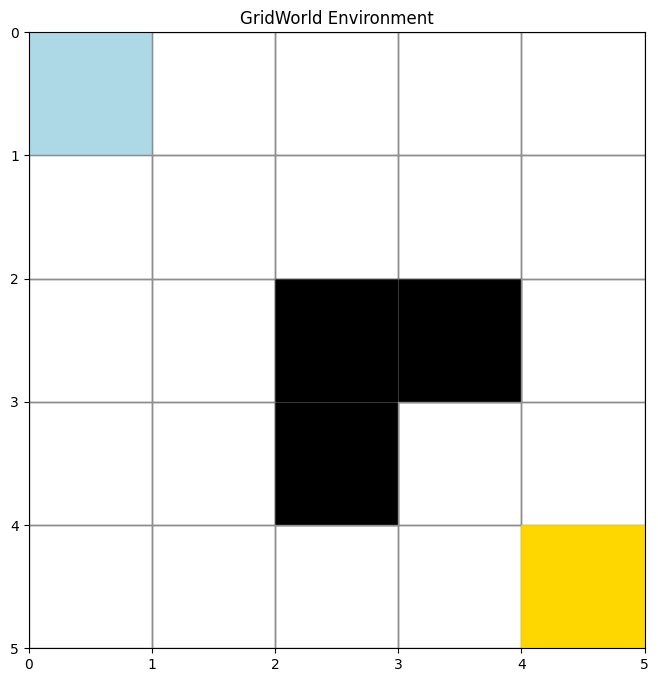

Actions: ['up', 'down', 'left', 'right']
Start: (0, 0), Goal: (4, 4)


In [2]:
class GridWorld:
    """Simple GridWorld environment for testing model-based RL."""
    
    def __init__(self, size=5, goal=(4, 4), obstacles=None):
        self.size = size
        self.goal = goal
        self.obstacles = obstacles if obstacles else [(2, 2), (2, 3), (3, 2)]
        self.actions = ['up', 'down', 'left', 'right']
        self.action_to_delta = {
            'up': (-1, 0),
            'down': (1, 0),
            'left': (0, -1),
            'right': (0, 1)
        }
        self.reset()
    
    def reset(self):
        """Reset to starting position."""
        self.state = (0, 0)
        return self.state
    
    def step(self, action):
        """Execute action and return (next_state, reward, done)."""
        row, col = self.state
        dr, dc = self.action_to_delta[action]
        
        # Compute new position
        new_row = max(0, min(self.size - 1, row + dr))
        new_col = max(0, min(self.size - 1, col + dc))
        new_state = (new_row, new_col)
        
        # Check if hit obstacle (stay in place)
        if new_state in self.obstacles:
            new_state = self.state
        
        # Compute reward
        if new_state == self.goal:
            reward = 100  # Big reward for reaching goal
            done = True
        else:
            reward = -1  # Small penalty for each step
            done = False
        
        self.state = new_state
        return new_state, reward, done
    
    def get_all_states(self):
        """Return all valid states."""
        states = []
        for r in range(self.size):
            for c in range(self.size):
                if (r, c) not in self.obstacles:
                    states.append((r, c))
        return states
    
    def visualize(self, q_values=None, policy=None):
        """Visualize the grid with optional Q-values or policy."""
        fig, ax = plt.subplots(figsize=(8, 8))
        
        # Draw grid
        for r in range(self.size):
            for c in range(self.size):
                if (r, c) in self.obstacles:
                    ax.add_patch(plt.Rectangle((c, r), 1, 1, color='black'))
                elif (r, c) == self.goal:
                    ax.add_patch(plt.Rectangle((c, r), 1, 1, color='gold'))
                elif (r, c) == self.state:
                    ax.add_patch(plt.Rectangle((c, r), 1, 1, color='lightblue'))
                else:
                    ax.add_patch(plt.Rectangle((c, r), 1, 1, fill=False, edgecolor='gray'))
                
                # Draw policy arrows if provided
                if policy and (r, c) in policy:
                    action = policy[(r, c)]
                    if action in self.action_to_delta:
                        dr, dc = self.action_to_delta[action]
                        ax.arrow(c + 0.5, r + 0.5, dc * 0.3, dr * 0.3,
                                head_width=0.15, head_length=0.1, fc='blue', ec='blue')
        
        ax.set_xlim(0, self.size)
        ax.set_ylim(0, self.size)
        ax.set_aspect('equal')
        ax.invert_yaxis()
        ax.set_xticks(range(self.size + 1))
        ax.set_yticks(range(self.size + 1))
        ax.grid(True, alpha=0.3)
        ax.set_title('GridWorld Environment')
        plt.show()

# Create environment
env = GridWorld()
env.visualize()
print(f"Actions: {env.actions}")
print(f"Start: {env.state}, Goal: {env.goal}")

## 2. Baseline: Model-Free Q-Learning

First, let's implement standard Q-learning as our baseline. This will help us compare performance with model-based approaches.

**Recall Q-learning update:**
$$Q(s, a) \leftarrow Q(s, a) + \alpha [r + \gamma \max_{a'} Q(s', a') - Q(s, a)]$$

This learns directly from real environment interactions.

In [3]:
class QLearningAgent:
    """Standard model-free Q-learning agent."""
    
    def __init__(self, actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.actions = actions
        self.alpha = alpha      # Learning rate
        self.gamma = gamma      # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.q_table = defaultdict(lambda: defaultdict(float))
    
    def get_action(self, state):
        """Epsilon-greedy action selection."""
        if random.random() < self.epsilon:
            return random.choice(self.actions)
        else:
            q_values = {a: self.q_table[state][a] for a in self.actions}
            max_q = max(q_values.values())
            # Handle ties randomly
            best_actions = [a for a, q in q_values.items() if q == max_q]
            return random.choice(best_actions)
    
    def update(self, state, action, reward, next_state):
        """Q-learning update from real experience."""
        # Current Q-value
        current_q = self.q_table[state][action]
        
        # Max Q-value for next state
        max_next_q = max([self.q_table[next_state][a] for a in self.actions])
        
        # TD target and error
        td_target = reward + self.gamma * max_next_q
        td_error = td_target - current_q
        
        # Update Q-value
        self.q_table[state][action] += self.alpha * td_error
    
    def get_policy(self):
        """Extract greedy policy from Q-values."""
        policy = {}
        for state in self.q_table:
            q_values = {a: self.q_table[state][a] for a in self.actions}
            policy[state] = max(q_values, key=q_values.get)
        return policy

print("Model-Free Q-Learning Agent created")
print("This agent learns ONLY from real environment interactions")

Model-Free Q-Learning Agent created
This agent learns ONLY from real environment interactions


### Training Model-Free Agent

Let's train the Q-learning agent and track its performance.

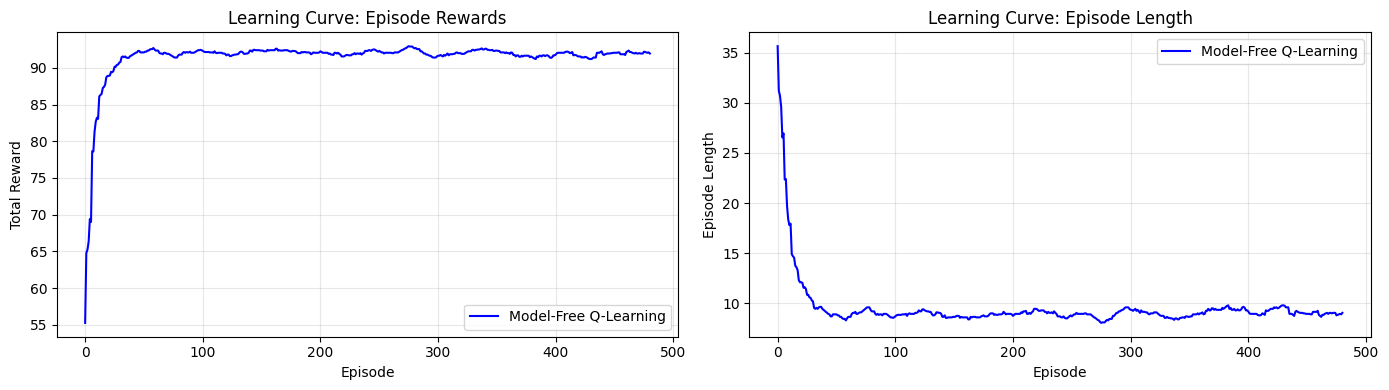

Final average reward (last 50 episodes): 92.02
Final average length (last 50 episodes): 8.98


In [4]:
def train_agent(env, agent, episodes=500, max_steps=100):
    """Train an agent and track performance."""
    episode_rewards = []
    episode_lengths = []
    
    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        
        for step in range(max_steps):
            action = agent.get_action(state)
            next_state, reward, done = env.step(action)
            
            agent.update(state, action, reward, next_state)
            
            total_reward += reward
            state = next_state
            
            if done:
                break
        
        episode_rewards.append(total_reward)
        episode_lengths.append(step + 1)
    
    return episode_rewards, episode_lengths

# Train model-free agent
mf_agent = QLearningAgent(env.actions)
mf_rewards, mf_lengths = train_agent(env, mf_agent, episodes=500)

# Plot learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Moving average for smoothing
window = 20
mf_rewards_smooth = np.convolve(mf_rewards, np.ones(window)/window, mode='valid')
mf_lengths_smooth = np.convolve(mf_lengths, np.ones(window)/window, mode='valid')

ax1.plot(mf_rewards_smooth, label='Model-Free Q-Learning', color='blue')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward')
ax1.set_title('Learning Curve: Episode Rewards')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(mf_lengths_smooth, label='Model-Free Q-Learning', color='blue')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Episode Length')
ax2.set_title('Learning Curve: Episode Length')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final average reward (last 50 episodes): {np.mean(mf_rewards[-50:]):.2f}")
print(f"Final average length (last 50 episodes): {np.mean(mf_lengths[-50:]):.2f}")

### Visualize Learned Policy

Let's see what policy the model-free agent learned.

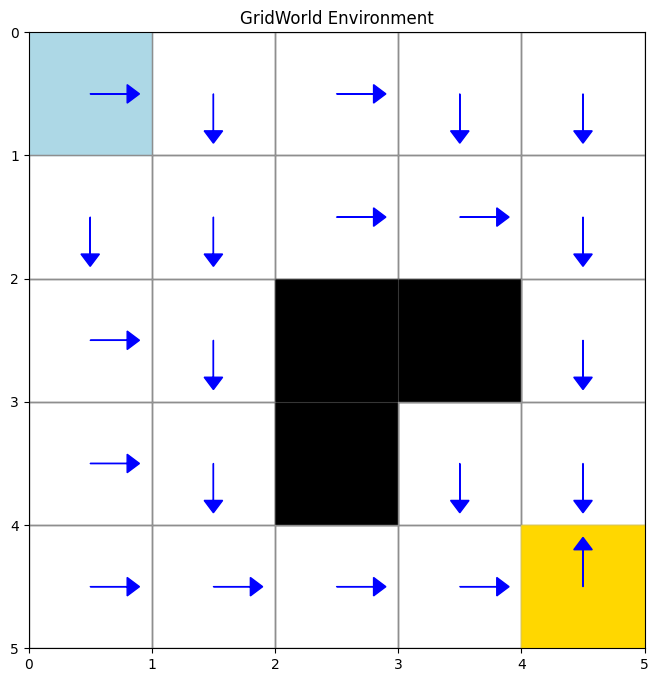

Blue arrows show the learned policy (best action in each state)


In [5]:
env.reset()
mf_policy = mf_agent.get_policy()
env.visualize(policy=mf_policy)
print("Blue arrows show the learned policy (best action in each state)")

## 3. World Model: Learning Environment Dynamics

Now let's build a **world model** that learns to predict:
- **Transition function**: $P(s' | s, a)$ - what state do we reach?
- **Reward function**: $R(s, a)$ - what reward do we get?

For a deterministic environment like GridWorld, we can use a simple **tabular model** that stores observed transitions.

In more complex environments, we'd use neural networks as function approximators.

In [6]:
class WorldModel:
    """Learns a model of the environment dynamics."""
    
    def __init__(self):
        # Store transitions: model[(state, action)] = (next_state, reward)
        self.model = {}
        # Track which (state, action) pairs we've experienced
        self.experienced = set()
    
    def add_experience(self, state, action, next_state, reward):
        """Record a transition from real environment interaction."""
        self.model[(state, action)] = (next_state, reward)
        self.experienced.add((state, action))
    
    def predict(self, state, action):
        """Predict next state and reward using the learned model."""
        if (state, action) in self.model:
            return self.model[(state, action)]
        else:
            # Unknown transition - return None
            return None, None
    
    def sample_experience(self):
        """Sample a random previously experienced (state, action) pair."""
        if not self.experienced:
            return None, None
        state, action = random.choice(list(self.experienced))
        next_state, reward = self.model[(state, action)]
        return (state, action, next_state, reward)
    
    def get_known_transitions(self):
        """Return number of known state-action pairs."""
        return len(self.experienced)

# Create a world model
world_model = WorldModel()
print("World Model created")
print("This model will learn to predict: (next_state, reward) = f(state, action)")

World Model created
This model will learn to predict: (next_state, reward) = f(state, action)


### Testing the World Model

Let's manually collect some experiences and see if the model learns correctly.

In [7]:
# Collect some real experiences
env.reset()
test_model = WorldModel()

print("Collecting experiences...")
for _ in range(20):
    state = env.state
    action = random.choice(env.actions)
    next_state, reward, done = env.step(action)
    
    # Add to model
    test_model.add_experience(state, action, next_state, reward)
    print(f"  Real: s={state}, a={action:5s} → s'={next_state}, r={reward:4.0f}")
    
    if done:
        env.reset()

print(f"\nModel learned {test_model.get_known_transitions()} transitions")

# Test predictions
print("\nTesting model predictions:")
env.reset()
for _ in range(5):
    state = env.state
    action = random.choice(env.actions)
    
    # Real environment
    real_next, real_reward, _ = env.step(action)
    
    # Model prediction
    pred_next, pred_reward = test_model.predict(state, action)
    
    if pred_next is not None:
        match = "✓" if (pred_next == real_next and pred_reward == real_reward) else "✗"
        print(f"  {match} s={state}, a={action:5s}: Real=({real_next}, {real_reward:4.0f}), "
              f"Pred=({pred_next}, {pred_reward:4.0f})")
    else:
        print(f"  ? s={state}, a={action:5s}: Unknown to model")

  Real: s=(0, 0), a=up    → s'=(0, 0), r=  -1
  Real: s=(0, 0), a=right → s'=(0, 1), r=  -1
  Real: s=(0, 1), a=down  → s'=(1, 1), r=  -1
  Real: s=(1, 1), a=left  → s'=(1, 0), r=  -1
  Real: s=(1, 0), a=left  → s'=(1, 0), r=  -1
  Real: s=(1, 0), a=left  → s'=(1, 0), r=  -1
  Real: s=(1, 0), a=right → s'=(1, 1), r=  -1
  Real: s=(1, 1), a=down  → s'=(2, 1), r=  -1
  Real: s=(2, 1), a=down  → s'=(3, 1), r=  -1
  Real: s=(3, 1), a=down  → s'=(4, 1), r=  -1
  Real: s=(4, 1), a=down  → s'=(4, 1), r=  -1
  Real: s=(4, 1), a=up    → s'=(3, 1), r=  -1
  Real: s=(3, 1), a=down  → s'=(4, 1), r=  -1
  Real: s=(4, 1), a=up    → s'=(3, 1), r=  -1
  Real: s=(3, 1), a=up    → s'=(2, 1), r=  -1
  Real: s=(2, 1), a=down  → s'=(3, 1), r=  -1
  Real: s=(3, 1), a=right → s'=(3, 1), r=  -1
  Real: s=(3, 1), a=left  → s'=(3, 0), r=  -1
  Real: s=(3, 0), a=up    → s'=(2, 0), r=  -1
  Real: s=(2, 0), a=down  → s'=(3, 0), r=  -1

Model learned 16 transitions

Testing model predictions:
  ✓ s=(0, 0), a=up   :

**Key insight:** The world model can perfectly predict transitions it has observed. This means we can "simulate" the environment!

## 4. Dyna Algorithm: Combining Real and Simulated Experience

**The Dyna algorithm** integrates model-free and model-based RL:

1. **Direct RL**: Learn from real environment interactions (like Q-learning)
2. **Model Learning**: Update the world model with each real transition
3. **Planning**: Use the model to generate simulated experiences and learn from them too!

**Algorithm:**
```
For each episode:
    For each step:
        1. Take action in real environment
        2. Update Q-values from real experience (direct RL)
        3. Update world model with this transition (model learning)
        4. Do N planning steps:
            - Sample random (s, a) from model
            - Predict (s', r) using model
            - Update Q-values from simulated experience (planning)
```

**Why this works:** We learn from BOTH real experiences AND simulated experiences, dramatically improving sample efficiency!

In [8]:
class DynaAgent:
    """Dyna agent combining model-free RL with model-based planning."""
    
    def __init__(self, actions, alpha=0.1, gamma=0.9, epsilon=0.1, planning_steps=5):
        self.actions = actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.planning_steps = planning_steps  # Number of planning steps per real step
        
        self.q_table = defaultdict(lambda: defaultdict(float))
        self.model = WorldModel()
        
        # Track statistics
        self.real_updates = 0
        self.simulated_updates = 0
    
    def get_action(self, state):
        """Epsilon-greedy action selection."""
        if random.random() < self.epsilon:
            return random.choice(self.actions)
        else:
            q_values = {a: self.q_table[state][a] for a in self.actions}
            max_q = max(q_values.values())
            best_actions = [a for a, q in q_values.items() if q == max_q]
            return random.choice(best_actions)
    
    def update_q(self, state, action, reward, next_state):
        """Update Q-values (same for real and simulated experiences)."""
        current_q = self.q_table[state][action]
        max_next_q = max([self.q_table[next_state][a] for a in self.actions])
        td_target = reward + self.gamma * max_next_q
        td_error = td_target - current_q
        self.q_table[state][action] += self.alpha * td_error
    
    def update(self, state, action, reward, next_state):
        """Full Dyna update: direct RL + model learning + planning."""
        # 1. Direct RL: update from real experience
        self.update_q(state, action, reward, next_state)
        self.real_updates += 1
        
        # 2. Model learning: add transition to world model
        self.model.add_experience(state, action, next_state, reward)
        
        # 3. Planning: learn from simulated experiences
        for _ in range(self.planning_steps):
            # Sample a random previously seen (state, action)
            sim_state, sim_action, sim_next, sim_reward = self.model.sample_experience()
            if sim_state is not None:
                # Update Q-values using simulated experience
                self.update_q(sim_state, sim_action, sim_reward, sim_next)
                self.simulated_updates += 1
    
    def get_policy(self):
        """Extract greedy policy."""
        policy = {}
        for state in self.q_table:
            q_values = {a: self.q_table[state][a] for a in self.actions}
            policy[state] = max(q_values, key=q_values.get)
        return policy

print("Dyna Agent created")
print("This agent learns from BOTH real and simulated experiences!")

Dyna Agent created
This agent learns from BOTH real and simulated experiences!


### Training Dyna Agent

Let's train Dyna and compare it to model-free Q-learning. We expect Dyna to learn faster because it makes better use of each real experience through planning.

In [9]:
# Train Dyna agent with different planning steps
planning_steps_list = [0, 5, 10, 20]
results = {}

for planning_steps in planning_steps_list:
    print(f"\nTraining Dyna with {planning_steps} planning steps...")
    env.reset()
    dyna_agent = DynaAgent(env.actions, planning_steps=planning_steps)
    rewards, lengths = train_agent(env, dyna_agent, episodes=500)
    results[planning_steps] = (rewards, lengths, dyna_agent)
    print(f"  Real updates: {dyna_agent.real_updates:,}")
    print(f"  Simulated updates: {dyna_agent.simulated_updates:,}")
    print(f"  Ratio: {dyna_agent.simulated_updates / max(1, dyna_agent.real_updates):.1f}x")


Training Dyna with 0 planning steps...
  Real updates: 5,042
  Simulated updates: 0
  Ratio: 0.0x

Training Dyna with 5 planning steps...


  Real updates: 4,609
  Simulated updates: 23,045
  Ratio: 5.0x

Training Dyna with 10 planning steps...


  Real updates: 4,685
  Simulated updates: 46,850
  Ratio: 10.0x

Training Dyna with 20 planning steps...


  Real updates: 4,587
  Simulated updates: 91,740
  Ratio: 20.0x


### Comparison: Model-Free vs Model-Based

Let's visualize how planning steps affect learning speed.

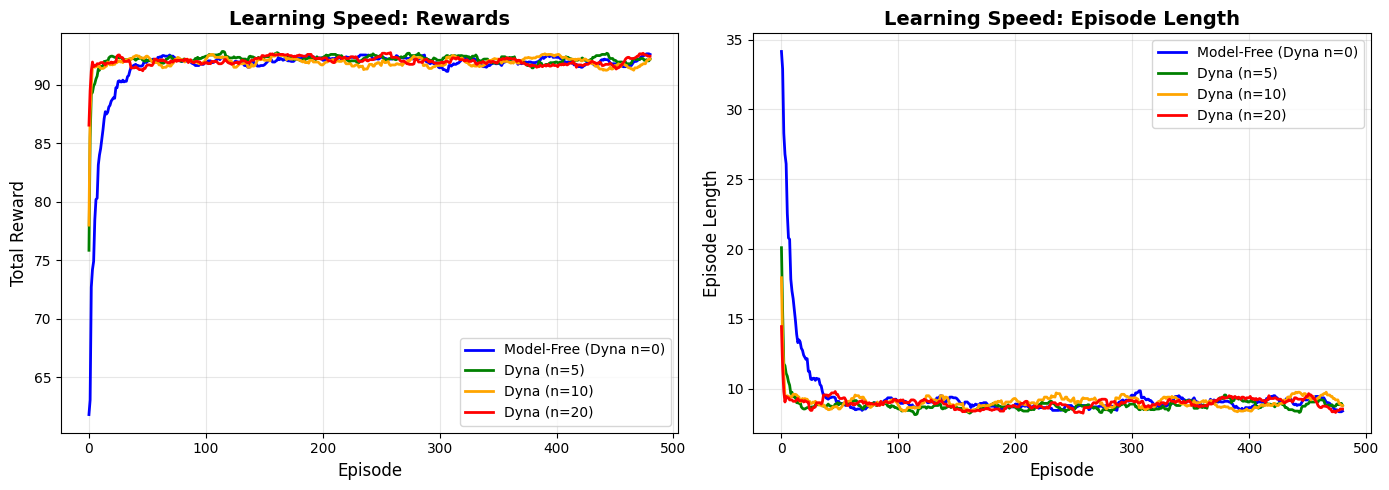


Final Performance (last 50 episodes):
  Model-Free          : Reward= 92.08, Length= 8.92
  Dyna (n=5)          : Reward= 92.14, Length= 8.86
  Dyna (n=10)         : Reward= 91.78, Length= 9.22
  Dyna (n=20)         : Reward= 92.08, Length= 8.92


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['blue', 'green', 'orange', 'red']
window = 20

for (planning_steps, (rewards, lengths, agent)), color in zip(results.items(), colors):
    rewards_smooth = np.convolve(rewards, np.ones(window)/window, mode='valid')
    lengths_smooth = np.convolve(lengths, np.ones(window)/window, mode='valid')
    
    label = f'Dyna (n={planning_steps})' if planning_steps > 0 else 'Model-Free (Dyna n=0)'
    
    ax1.plot(rewards_smooth, label=label, color=color, linewidth=2)
    ax2.plot(lengths_smooth, label=label, color=color, linewidth=2)

ax1.set_xlabel('Episode', fontsize=12)
ax1.set_ylabel('Total Reward', fontsize=12)
ax1.set_title('Learning Speed: Rewards', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Episode', fontsize=12)
ax2.set_ylabel('Episode Length', fontsize=12)
ax2.set_title('Learning Speed: Episode Length', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final performance
print("\nFinal Performance (last 50 episodes):")
for planning_steps in planning_steps_list:
    rewards, lengths, _ = results[planning_steps]
    label = f'Dyna (n={planning_steps})' if planning_steps > 0 else 'Model-Free'
    print(f"  {label:20s}: Reward={np.mean(rewards[-50:]):6.2f}, Length={np.mean(lengths[-50:]):5.2f}")

**Key Observations:**

1. **More planning = faster learning**: Agents with more planning steps converge faster
2. **Sample efficiency**: Dyna agents learn from fewer real environment interactions
3. **Diminishing returns**: Beyond a certain point, more planning doesn't help much
4. **Computational cost**: More planning = more computation per step

This demonstrates the **fundamental trade-off in model-based RL**: computational cost vs sample efficiency.

## 5. Understanding Planning

Let's visualize what planning actually does. We'll track which state-action pairs get updated during planning vs direct experience.

In [11]:
class DynaAgentInstrumented(DynaAgent):
    """Dyna agent that tracks what it updates."""
    
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.real_updates_map = defaultdict(int)
        self.sim_updates_map = defaultdict(int)
    
    def update(self, state, action, reward, next_state):
        # Track real update
        self.real_updates_map[state] += 1
        
        # Direct RL
        self.update_q(state, action, reward, next_state)
        self.real_updates += 1
        
        # Model learning
        self.model.add_experience(state, action, next_state, reward)
        
        # Planning - track simulated updates
        for _ in range(self.planning_steps):
            sim_state, sim_action, sim_next, sim_reward = self.model.sample_experience()
            if sim_state is not None:
                self.sim_updates_map[sim_state] += 1
                self.update_q(sim_state, sim_action, sim_reward, sim_next)
                self.simulated_updates += 1

# Train instrumented agent
env.reset()
instrumented_agent = DynaAgentInstrumented(env.actions, planning_steps=10)
train_agent(env, instrumented_agent, episodes=200)

([8,
  90,
  57,
  91,
  86,
  85,
  92,
  93,
  92,
  92,
  93,
  93,
  93,
  93,
  93,
  93,
  91,
  91,
  93,
  93,
  92,
  93,
  93,
  93,
  93,
  92,
  93,
  93,
  92,
  93,
  92,
  91,
  92,
  93,
  93,
  92,
  93,
  93,
  92,
  91,
  93,
  93,
  93,
  93,
  93,
  93,
  93,
  90,
  93,
  91,
  93,
  93,
  92,
  93,
  93,
  92,
  88,
  93,
  91,
  91,
  93,
  92,
  91,
  93,
  93,
  93,
  93,
  91,
  92,
  91,
  91,
  93,
  93,
  93,
  93,
  93,
  93,
  92,
  90,
  93,
  93,
  92,
  91,
  93,
  88,
  92,
  92,
  93,
  91,
  92,
  91,
  93,
  93,
  93,
  93,
  93,
  93,
  93,
  91,
  93,
  91,
  93,
  92,
  93,
  93,
  91,
  91,
  93,
  93,
  93,
  93,
  93,
  92,
  93,
  93,
  93,
  93,
  91,
  85,
  90,
  93,
  93,
  91,
  92,
  93,
  93,
  91,
  92,
  93,
  91,
  93,
  93,
  93,
  91,
  93,
  93,
  93,
  92,
  93,
  93,
  93,
  92,
  92,
  92,
  91,
  93,
  89,
  92,
  92,
  93,
  93,
  93,
  91,
  93,
  93,
  93,
  93,
  93,
  92,
  92,
  93,
  92,
  93,
  93,
  93,
  93,
  93,

### Visualize Update Distribution

Let's see which states benefit most from planning.

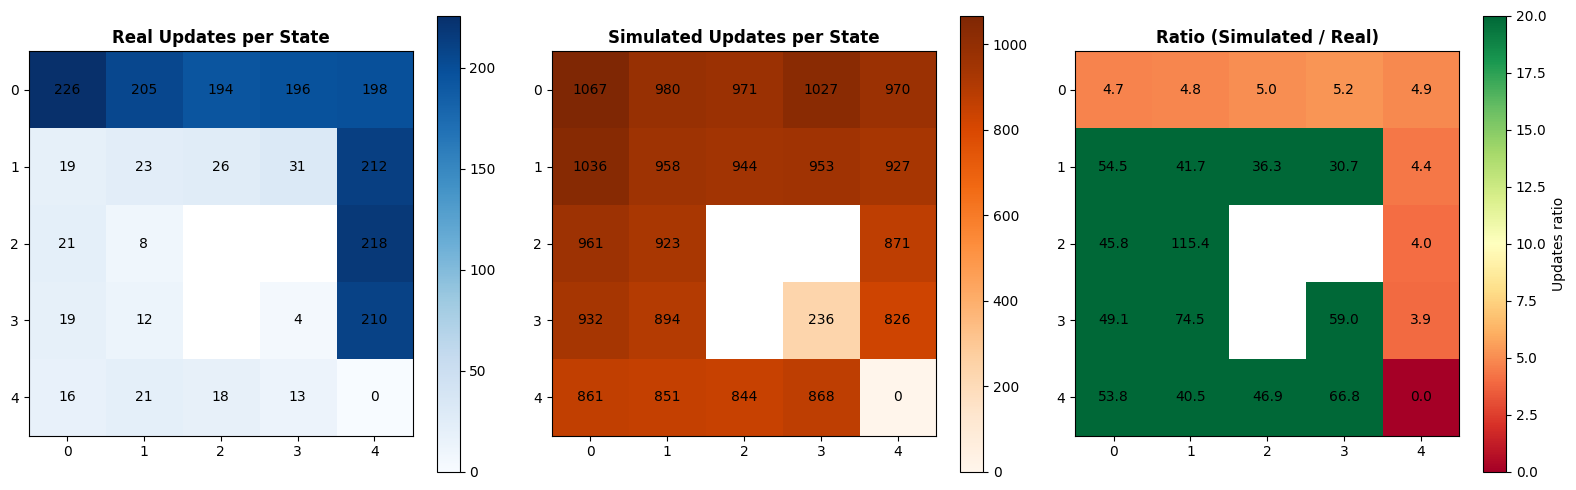


Insight: Planning 'spreads' learning by repeatedly updating states
even when the agent doesn't visit them in real experience!


In [12]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# Create grids for visualization
size = env.size
real_grid = np.zeros((size, size))
sim_grid = np.zeros((size, size))
ratio_grid = np.zeros((size, size))

for r in range(size):
    for c in range(size):
        state = (r, c)
        if state not in env.obstacles:
            real_count = instrumented_agent.real_updates_map[state]
            sim_count = instrumented_agent.sim_updates_map[state]
            
            real_grid[r, c] = real_count
            sim_grid[r, c] = sim_count
            ratio_grid[r, c] = sim_count / max(1, real_count)
        else:
            real_grid[r, c] = np.nan
            sim_grid[r, c] = np.nan
            ratio_grid[r, c] = np.nan

# Plot real updates
im1 = ax1.imshow(real_grid, cmap='Blues', interpolation='nearest')
ax1.set_title('Real Updates per State', fontsize=12, fontweight='bold')
for r in range(size):
    for c in range(size):
        if not np.isnan(real_grid[r, c]):
            ax1.text(c, r, f'{int(real_grid[r, c])}', ha='center', va='center', fontsize=10)
plt.colorbar(im1, ax=ax1)

# Plot simulated updates
im2 = ax2.imshow(sim_grid, cmap='Oranges', interpolation='nearest')
ax2.set_title('Simulated Updates per State', fontsize=12, fontweight='bold')
for r in range(size):
    for c in range(size):
        if not np.isnan(sim_grid[r, c]):
            ax2.text(c, r, f'{int(sim_grid[r, c])}', ha='center', va='center', fontsize=10)
plt.colorbar(im2, ax=ax2)

# Plot ratio
im3 = ax3.imshow(ratio_grid, cmap='RdYlGn', interpolation='nearest', vmin=0, vmax=20)
ax3.set_title('Ratio (Simulated / Real)', fontsize=12, fontweight='bold')
for r in range(size):
    for c in range(size):
        if not np.isnan(ratio_grid[r, c]):
            ax3.text(c, r, f'{ratio_grid[r, c]:.1f}', ha='center', va='center', fontsize=10)
plt.colorbar(im3, ax=ax3, label='Updates ratio')

for ax in [ax1, ax2, ax3]:
    ax.set_xticks(range(size))
    ax.set_yticks(range(size))

plt.tight_layout()
plt.show()

print("\nInsight: Planning 'spreads' learning by repeatedly updating states")
print("even when the agent doesn't visit them in real experience!")

**Critical insight:** Planning allows the agent to learn about states it rarely visits! The simulated updates propagate value information throughout the state space more efficiently than real experience alone.

## 6. Prioritized Sweeping: Smarter Planning

Random sampling for planning is inefficient. **Prioritized Sweeping** prioritizes updates based on how much they'll change Q-values.

**Intuition**: If we just learned that reaching the goal gives +100 reward, we should immediately update all states that can reach the goal!

**Algorithm**: Maintain a priority queue of (state, action) pairs ordered by expected TD error magnitude.

In [13]:
import heapq

class PrioritizedSweepingAgent:
    """Dyna agent with prioritized sweeping."""
    
    def __init__(self, actions, alpha=0.1, gamma=0.9, epsilon=0.1, planning_steps=5, theta=0.01):
        self.actions = actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.planning_steps = planning_steps
        self.theta = theta  # Minimum priority threshold
        
        self.q_table = defaultdict(lambda: defaultdict(float))
        self.model = {}  # (s, a) -> (s', r)
        self.predecessors = defaultdict(set)  # s -> set of (s_prev, a) that lead to s
        
        # Priority queue: stores (-priority, (state, action))
        # Negative priority because heapq is a min-heap
        self.priority_queue = []
        self.in_queue = set()
    
    def get_action(self, state):
        """Epsilon-greedy action selection."""
        if random.random() < self.epsilon:
            return random.choice(self.actions)
        else:
            q_values = {a: self.q_table[state][a] for a in self.actions}
            max_q = max(q_values.values())
            best_actions = [a for a, q in q_values.items() if q == max_q]
            return random.choice(best_actions)
    
    def compute_priority(self, state, action):
        """Compute TD error magnitude for prioritization."""
        if (state, action) not in self.model:
            return 0
        
        next_state, reward = self.model[(state, action)]
        current_q = self.q_table[state][action]
        max_next_q = max([self.q_table[next_state][a] for a in self.actions])
        td_target = reward + self.gamma * max_next_q
        priority = abs(td_target - current_q)
        return priority
    
    def update_q(self, state, action):
        """Update Q-value for (state, action)."""
        if (state, action) not in self.model:
            return
        
        next_state, reward = self.model[(state, action)]
        current_q = self.q_table[state][action]
        max_next_q = max([self.q_table[next_state][a] for a in self.actions])
        td_target = reward + self.gamma * max_next_q
        td_error = td_target - current_q
        self.q_table[state][action] += self.alpha * td_error
        return abs(td_error)
    
    def add_to_queue(self, state, action, priority):
        """Add (state, action) to priority queue if priority > threshold."""
        if priority > self.theta and (state, action) not in self.in_queue:
            heapq.heappush(self.priority_queue, (-priority, (state, action)))
            self.in_queue.add((state, action))
    
    def update(self, state, action, reward, next_state):
        """Prioritized sweeping update."""
        # Update model and predecessors
        self.model[(state, action)] = (next_state, reward)
        self.predecessors[next_state].add((state, action))
        
        # Compute priority and add to queue
        priority = self.compute_priority(state, action)
        self.add_to_queue(state, action, priority)
        
        # Planning: process top priority items
        for _ in range(self.planning_steps):
            if not self.priority_queue:
                break
            
            # Get highest priority (state, action)
            _, (s, a) = heapq.heappop(self.priority_queue)
            self.in_queue.remove((s, a))
            
            # Update Q-value
            self.update_q(s, a)
            
            # Update priorities of predecessor states
            for pred_state, pred_action in self.predecessors[s]:
                pred_priority = self.compute_priority(pred_state, pred_action)
                self.add_to_queue(pred_state, pred_action, pred_priority)
    
    def get_policy(self):
        """Extract greedy policy."""
        policy = {}
        for state in self.q_table:
            q_values = {a: self.q_table[state][a] for a in self.actions}
            policy[state] = max(q_values, key=q_values.get)
        return policy

print("Prioritized Sweeping Agent created")
print("This agent prioritizes planning updates based on expected impact!")

Prioritized Sweeping Agent created
This agent prioritizes planning updates based on expected impact!


### Compare Random vs Prioritized Planning

Let's see if prioritized sweeping learns faster than random planning.

Training Random Planning Dyna...

Training Prioritized Sweeping Dyna...


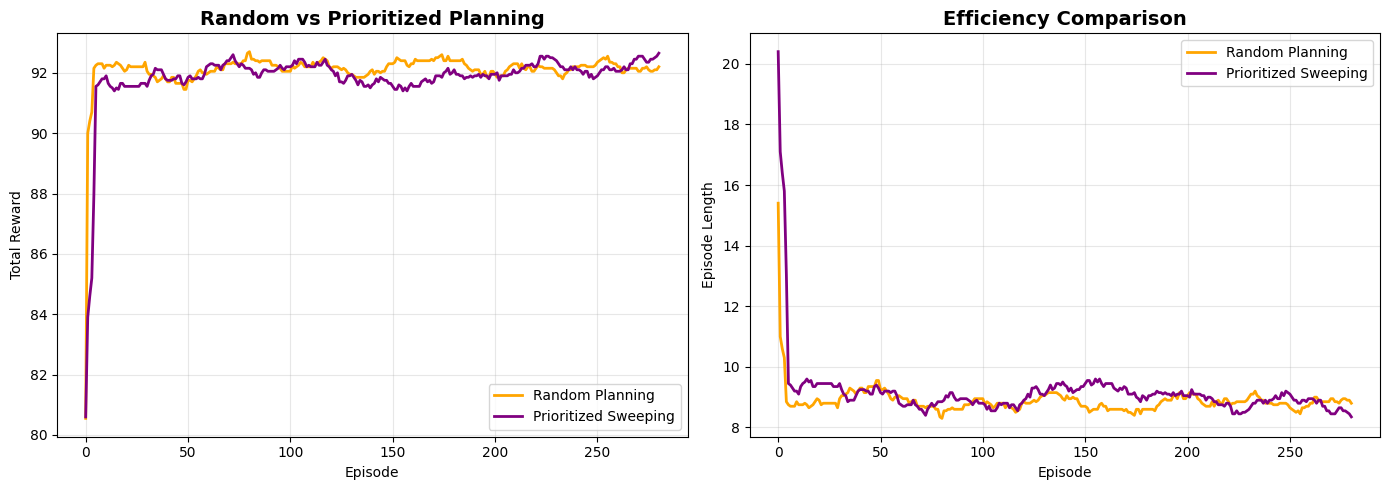


Final Performance (last 50 episodes):
  Random Planning:      Reward= 92.16
  Prioritized Sweeping: Reward= 92.28


In [14]:
# Train both agents
print("Training Random Planning Dyna...")
env.reset()
random_agent = DynaAgent(env.actions, planning_steps=10)
random_rewards, random_lengths = train_agent(env, random_agent, episodes=300)

print("\nTraining Prioritized Sweeping Dyna...")
env.reset()
prioritized_agent = PrioritizedSweepingAgent(env.actions, planning_steps=10)
prioritized_rewards, prioritized_lengths = train_agent(env, prioritized_agent, episodes=300)

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

window = 20
random_smooth = np.convolve(random_rewards, np.ones(window)/window, mode='valid')
prioritized_smooth = np.convolve(prioritized_rewards, np.ones(window)/window, mode='valid')

ax1.plot(random_smooth, label='Random Planning', color='orange', linewidth=2)
ax1.plot(prioritized_smooth, label='Prioritized Sweeping', color='purple', linewidth=2)
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward')
ax1.set_title('Random vs Prioritized Planning', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

random_lengths_smooth = np.convolve(random_lengths, np.ones(window)/window, mode='valid')
prioritized_lengths_smooth = np.convolve(prioritized_lengths, np.ones(window)/window, mode='valid')

ax2.plot(random_lengths_smooth, label='Random Planning', color='orange', linewidth=2)
ax2.plot(prioritized_lengths_smooth, label='Prioritized Sweeping', color='purple', linewidth=2)
ax2.set_xlabel('Episode')
ax2.set_ylabel('Episode Length')
ax2.set_title('Efficiency Comparison', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Performance (last 50 episodes):")
print(f"  Random Planning:      Reward={np.mean(random_rewards[-50:]):6.2f}")
print(f"  Prioritized Sweeping: Reward={np.mean(prioritized_rewards[-50:]):6.2f}")

**Key insight:** Prioritized sweeping focuses computational resources where they matter most, leading to more efficient learning!

## 7. Model Errors and Their Impact

A critical challenge in model-based RL: **what if the model is wrong?**

Let's explore how model errors affect learning by introducing a **stochastic environment** where the same action can lead to different outcomes.

In [15]:
class StochasticGridWorld(GridWorld):
    """GridWorld with stochastic transitions."""
    
    def __init__(self, size=5, goal=(4, 4), obstacles=None, slip_prob=0.2):
        super().__init__(size, goal, obstacles)
        self.slip_prob = slip_prob  # Probability of random action
    
    def step(self, action):
        """Execute action with some randomness."""
        # With probability slip_prob, take a random action instead
        if random.random() < self.slip_prob:
            action = random.choice(self.actions)
        
        return super().step(action)

# Create stochastic environment
stoch_env = StochasticGridWorld(slip_prob=0.2)
print(f"Stochastic GridWorld created with {stoch_env.slip_prob*100}% slip probability")
print("The agent might slip and take a random action!")

Stochastic GridWorld created with 20.0% slip probability
The agent might slip and take a random action!


### Testing in Stochastic Environment

Let's see how our tabular model handles stochasticity.

Training Model-Free Q-Learning on stochastic environment...

Training Dyna on stochastic environment...


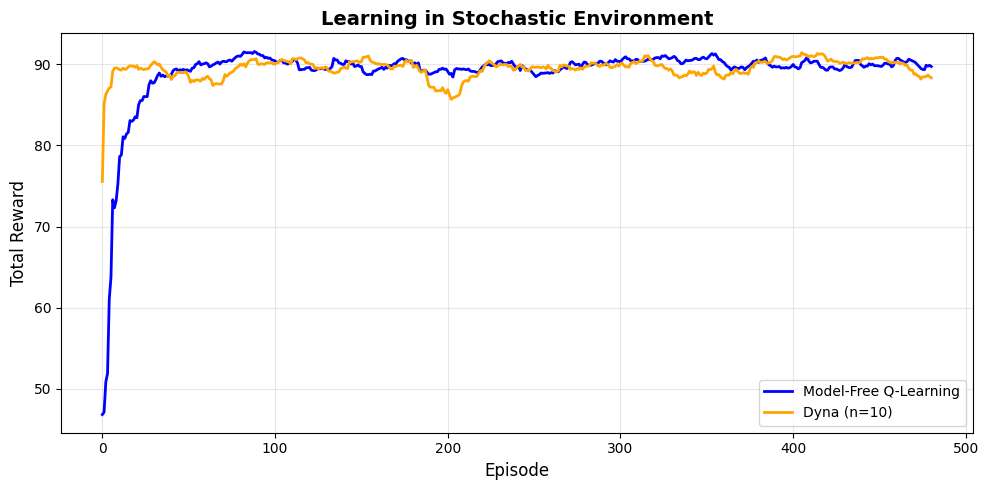


Final Performance in Stochastic Environment:
  Model-Free:  89.94
  Dyna:        89.56

Notice: Dyna still helps even in stochastic environments!
The model learns average outcomes, which is useful for planning.


In [16]:
# Train agents on stochastic environment
print("Training Model-Free Q-Learning on stochastic environment...")
stoch_env.reset()
mf_stoch = QLearningAgent(stoch_env.actions)
mf_stoch_rewards, _ = train_agent(stoch_env, mf_stoch, episodes=500)

print("\nTraining Dyna on stochastic environment...")
stoch_env.reset()
dyna_stoch = DynaAgent(stoch_env.actions, planning_steps=10)
dyna_stoch_rewards, _ = train_agent(stoch_env, dyna_stoch, episodes=500)

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 5))

window = 20
mf_smooth = np.convolve(mf_stoch_rewards, np.ones(window)/window, mode='valid')
dyna_smooth = np.convolve(dyna_stoch_rewards, np.ones(window)/window, mode='valid')

ax.plot(mf_smooth, label='Model-Free Q-Learning', color='blue', linewidth=2)
ax.plot(dyna_smooth, label='Dyna (n=10)', color='orange', linewidth=2)
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Total Reward', fontsize=12)
ax.set_title('Learning in Stochastic Environment', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFinal Performance in Stochastic Environment:")
print(f"  Model-Free: {np.mean(mf_stoch_rewards[-50:]):6.2f}")
print(f"  Dyna:       {np.mean(dyna_stoch_rewards[-50:]):6.2f}")
print("\nNotice: Dyna still helps even in stochastic environments!")
print("The model learns average outcomes, which is useful for planning.")

**Key insight:** Even with model errors, planning can still improve learning. The model learns the **expected** dynamics, which is often good enough!

## 8. Full Planning: Model-Based Policy Iteration

Dyna uses the model for **background planning** (random sampling). But we can also do **full planning**: given a complete model, compute the optimal policy directly!

This is essentially **value iteration** using the learned model.

In [17]:
def value_iteration_with_model(model, states, actions, gamma=0.9, theta=0.01, max_iterations=1000):
    """Perform value iteration using a learned model."""
    # Initialize value function
    V = defaultdict(float)
    
    for iteration in range(max_iterations):
        delta = 0
        
        # Update value for each state
        for state in states:
            if state not in model or len(model[state]) == 0:
                continue
            
            old_v = V[state]
            
            # Compute max over actions
            action_values = []
            for action in actions:
                if (state, action) in model:
                    next_state, reward = model[(state, action)]
                    action_value = reward + gamma * V[next_state]
                    action_values.append(action_value)
            
            if action_values:
                V[state] = max(action_values)
                delta = max(delta, abs(old_v - V[state]))
        
        if delta < theta:
            print(f"Value iteration converged in {iteration + 1} iterations")
            break
    
    # Extract policy
    policy = {}
    for state in states:
        if state not in model or len(model[state]) == 0:
            continue
        
        action_values = {}
        for action in actions:
            if (state, action) in model:
                next_state, reward = model[(state, action)]
                action_values[action] = reward + gamma * V[next_state]
        
        if action_values:
            policy[state] = max(action_values, key=action_values.get)
    
    return V, policy

print("Value iteration planner created")
print("Given a complete model, this computes the optimal policy directly!")

Value iteration planner created
Given a complete model, this computes the optimal policy directly!


### Using Full Planning

Let's first learn a model through exploration, then use value iteration to compute the optimal policy.

Phase 1: Exploring to learn world model...
Learned 84 state-action transitions

Phase 2: Computing optimal policy with value iteration...
Value iteration converged in 1 iterations
Policy computed for 0 states


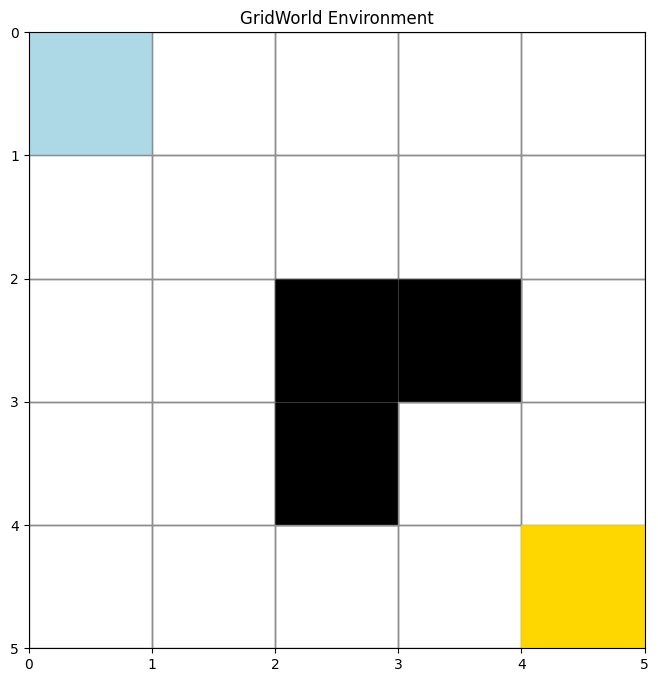

In [18]:
# Phase 1: Explore to learn model
env.reset()
exploration_model = {}

print("Phase 1: Exploring to learn world model...")
for episode in range(200):
    state = env.reset()
    for _ in range(50):
        action = random.choice(env.actions)
        next_state, reward, done = env.step(action)
        exploration_model[(state, action)] = (next_state, reward)
        state = next_state
        if done:
            break

print(f"Learned {len(exploration_model)} state-action transitions")

# Phase 2: Plan with learned model
print("\nPhase 2: Computing optimal policy with value iteration...")
states = env.get_all_states()
V, policy = value_iteration_with_model(exploration_model, states, env.actions)

print(f"Policy computed for {len(policy)} states")

# Visualize
env.reset()
env.visualize(policy=policy)

### Evaluate Learned Policy

Let's see how well this model-based policy performs.

In [19]:
def evaluate_policy(env, policy, episodes=100):
    """Evaluate a policy by running it in the environment."""
    total_rewards = []
    total_lengths = []
    
    for _ in range(episodes):
        state = env.reset()
        episode_reward = 0
        episode_length = 0
        
        for _ in range(100):
            if state not in policy:
                action = random.choice(env.actions)
            else:
                action = policy[state]
            
            next_state, reward, done = env.step(action)
            episode_reward += reward
            episode_length += 1
            state = next_state
            
            if done:
                break
        
        total_rewards.append(episode_reward)
        total_lengths.append(episode_length)
    
    return total_rewards, total_lengths

# Evaluate model-based policy
mb_rewards, mb_lengths = evaluate_policy(env, policy, episodes=100)

print("Model-Based Policy Performance:")
print(f"  Average reward: {np.mean(mb_rewards):.2f} ± {np.std(mb_rewards):.2f}")
print(f"  Average length: {np.mean(mb_lengths):.2f} ± {np.std(mb_lengths):.2f}")
print("\nThis demonstrates the classic model-based RL pipeline:")
print("1. Learn a model of the environment")
print("2. Use the model to plan (compute optimal policy)")
print("3. Execute the policy in the real environment")

Model-Based Policy Performance:
  Average reward: -23.05 ± 74.42
  Average length: 76.58 ± 27.83

This demonstrates the classic model-based RL pipeline:
1. Learn a model of the environment
2. Use the model to plan (compute optimal policy)
3. Execute the policy in the real environment


## 9. Model-Based vs Model-Free: The Trade-offs

Let's summarize the key trade-offs we've discovered.

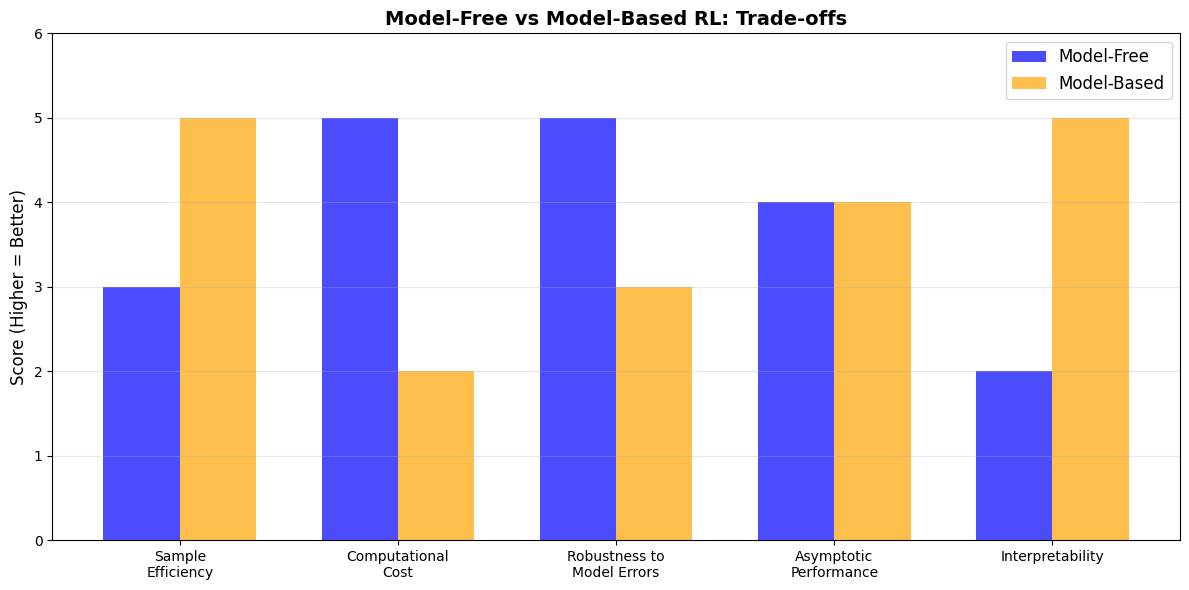

In [20]:
# Create comparison visualization
fig, ax = plt.subplots(figsize=(12, 6))

categories = ['Sample\nEfficiency', 'Computational\nCost', 'Robustness to\nModel Errors', 
              'Asymptotic\nPerformance', 'Interpretability']
x = np.arange(len(categories))

# Subjective scores (higher is better)
model_free_scores = [3, 5, 5, 4, 2]  # Model-free: simple but sample-hungry
model_based_scores = [5, 2, 3, 4, 5]  # Model-based: efficient but complex

width = 0.35
ax.bar(x - width/2, model_free_scores, width, label='Model-Free', color='blue', alpha=0.7)
ax.bar(x + width/2, model_based_scores, width, label='Model-Based', color='orange', alpha=0.7)

ax.set_ylabel('Score (Higher = Better)', fontsize=12)
ax.set_title('Model-Free vs Model-Based RL: Trade-offs', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(fontsize=12)
ax.set_ylim(0, 6)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Key Takeaways

### Model-Based RL Fundamentals

1. **World Models**: Learn dynamics $P(s' | s, a)$ and rewards $R(s, a)$ to simulate the environment

2. **The Dyna Architecture**: Combines three learning sources:
   - Direct RL from real experiences
   - Model learning from real transitions
   - Planning using simulated experiences

3. **Sample Efficiency**: Model-based methods learn faster by extracting more information from each real experience through planning

4. **Planning Strategies**:
   - **Random planning**: Simple but inefficient
   - **Prioritized sweeping**: Focus updates where they matter most
   - **Full planning**: Given a complete model, compute optimal policy directly

### Practical Insights

5. **Model Errors**: Imperfect models can still improve learning by capturing expected dynamics

6. **Computational Trade-off**: More planning = faster learning but higher computational cost

7. **When to Use Model-Based RL**:
   - Real environment interactions are expensive (robotics, clinical trials)
   - Environment dynamics are relatively smooth and learnable
   - Computational resources are available
   - Need to plan ahead or test "what if" scenarios

8. **When to Use Model-Free RL**:
   - Environment is complex and hard to model
   - Unlimited cheap interactions available
   - Robustness to distributional shift is critical

### Modern Applications

9. **Deep World Models**: Neural networks can learn complex dynamics from high-dimensional observations (images, etc.)

10. **Hybrid Approaches**: State-of-the-art RL often combines model-free and model-based methods (e.g., MuZero, Dreamer)

---

**The Big Picture**: Model-based RL represents a different paradigm - instead of learning a policy directly from trial and error, we learn how the world works and use that knowledge to plan. This is fundamentally more sample-efficient but introduces new challenges around model accuracy and computational cost.